### Imports

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torchvision import transforms

import  wandb
import os


## depend to the files of the project
from Datasets.dataset import RARE, GreenChannelCLAHE, EndoscopyArtifactRemover
from methods.ResNet import resnet50

from utils import train_one_epoch, evaluate, load, save
from metrics import compute_metrics, log_wandb_curves

### Loading the WandB

In [2]:
key_file = './wandb-key.txt'

if os.path.exists(key_file):
    with open(key_file) as f:
        key = f.readline().strip()
    wandb.login(key=key)
else:
    print("Key file does not exist. Please create the key file with your wandb API key.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\USER\.netrc
wandb: Currently logged in as: sepehr-eslami2019 (face-estimation) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Arguments

In [3]:
seed = 3
wandb_enable = True

info = {'num_epoch' :5,
        'lr' : 0.03,
        'weight_decay' : 1e-06,
        'device' : 'cuda',
        'reset': True,
        'name_load' : 'test',
        'model_load_path' : './saved_model/',
        'model_save_path' : './saved_model/',
        'RARE_root_path' : "./Datasets/RARE25-train-data",
        'train_batch_size' : 64,
        'valid_batch_size' : 128
        }


Initialize `wandb`

In [4]:
wandb_run_id = 'resnet50_v1' 
wandb_arg_name = 'ResNet50'

wandb.init(
    project='RARE26test',
    name=wandb_arg_name,
    id=wandb_run_id,     
    resume='allow',     
    config={
        'lr': info['lr'],
        'weight_decay': info['weight_decay'],
        'num_epoch': info['num_epoch']
    }
)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


### Main Loop

In [5]:
loss_train_hist = []
loss_valid_hist = []

metric_train_hist = []
metric_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

Deffine the `Dataloader`

In [ ]:
train_transforms = transforms.Compose([
    EndoscopyArtifactRemover(target_size=(224, 224)),
    # Letterbox(224), 
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.0
        ),
        
    GreenChannelCLAHE(clip_limit=2.0, tile_size=(8, 8)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),
    ])

val_transforms = transforms.Compose([
        EndoscopyArtifactRemover(target_size=(224, 224)),
        GreenChannelCLAHE(clip_limit=2.0, tile_size=(8, 8)),

        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
    ])

In [ ]:
train_loader = RARE(info['RARE_root_path'], mode='train', transforms=train_transforms, mini=False)(batch_size=info['train_batch_size'])
valid_loader = RARE(info['RARE_root_path'], mode='valid', transforms=val_transforms, mini=False)(batch_size=info['valid_batch_size'])

Loaded dataset with 158 'neo' (neoplasia) images and 2937 'ndbe' (nondysplastic) images.
Loaded dataset with 158 'neo' (neoplasia) images and 2937 'ndbe' (nondysplastic) images.


 Define the `Model` - `Optimizer` - `Loss Function` - `Metric`

In [7]:
load_path = info['model_load_path'] + info['name_load'] + ".pth"

###############
#    Model    #
###############


model = resnet50(pretrained=True).to(info['device'])


optimizer = optim.SGD(model.parameters(), lr=info['lr'], weight_decay=info['weight_decay'], momentum=0.9)# , nesterov=True
# lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3, 6], gamma=0.5)

loss_fn = nn.BCEWithLogitsLoss().to(info['device'])

metric = compute_metrics

model, _, optimizer = load(model, optimizer, loss_fn=None, device = info['device'], reset = info['reset'], load_path=load_path)

save_path = info['model_save_path'] + info['name_load']+ ".pth"

**`Training`**

In [ ]:
epochs = info['num_epoch']

for epoch in range(1, epochs+1):
    ## Train
    model, train_epoch_metrics, train_y_true, train_y_scores = train_one_epoch(model,
                                                            # valid_loader,
                                                            train_loader,
                                                            loss_fn,
                                                            optimizer,
                                                            metric,
                                                            epoch,
                                                            device=info['device'])
    
    ## Validation
    valid_epoch_metrics, valid_y_true, valid_y_scores = evaluate(model,
                                              valid_loader,
                                              loss_fn,
                                              metric,
                                              device=info['device'])

        
    loss_train_hist.append(train_epoch_metrics['Loss'])
    loss_valid_hist.append(valid_epoch_metrics['Loss'])

    metric_train_hist.append(train_epoch_metrics['PPV@90% Recall'])
    metric_valid_hist.append(valid_epoch_metrics['PPV@90% Recall'])


    print(f'Train      - Loss:{train_epoch_metrics["Loss"]}  Metric:{train_epoch_metrics["PPV@90% Recall"]}')
    print(f'Validation - Loss:{valid_epoch_metrics["Loss"]}  Metric:{valid_epoch_metrics["PPV@90% Recall"]}')
    # print(f'LR = {lr_scheduler.get_last_lr()[0]}')
    print()

    if valid_epoch_metrics['Loss'] < best_loss_valid:
        save(save_path, model, optimizer, loss_fn)
        best_loss_valid = valid_epoch_metrics['Loss']
        print('Model Saved ("o")')

 
    skip_keys = {"Accuracy", "Sensitivity", "Specificity", "T90_Threshold",
                "T90_TP", "T90_FP", "T90_FN"}

    if wandb_enable:
        wandb_log_dict = {
            "Loss/train":        train_epoch_metrics["Loss"],
            "Loss/val":          valid_epoch_metrics["Loss"],
            "AUROC/train":       train_epoch_metrics["AUROC"],
            "AUROC/val":         valid_epoch_metrics["AUROC"],
            "AUPRC/train":       train_epoch_metrics["AUPRC"],
            "AUPRC/val":         valid_epoch_metrics["AUPRC"],
            "PPV@90Recall/train": train_epoch_metrics["PPV@90% Recall"],
            "PPV@90Recall/val":  valid_epoch_metrics["PPV@90% Recall"],
        }
        for key, value in train_epoch_metrics.items():
            if key.startswith("_") or key in skip_keys or key == "Loss": continue
            wandb_log_dict[f"train/{key}"] = value
        for key, value in valid_epoch_metrics.items():
            if key.startswith("_") or key in skip_keys or key == "Loss": continue
            wandb_log_dict[f"val/{key}"] = value

        wandb.log(wandb_log_dict, step=epoch)

        log_wandb_curves(train_epoch_metrics, "train", epoch)
        log_wandb_curves(valid_epoch_metrics, "val", epoch)

    epoch_counter += 1





Epoch 1: 100%|██████████| 39/39 [00:30<00:00,  1.27batch/s, loss=0.24] 


Train      - Loss:0.2397896647453308  Metric:0.05741387918122816
Validation - Loss:0.1625586897134781  Metric:0.08484848484848485

Checkpoint successfully saved to ./saved_model/test.pth
Model Saved ("o")


Epoch 2: 100%|██████████| 39/39 [00:30<00:00,  1.27batch/s, loss=0.142]


Train      - Loss:0.1415523737668991  Metric:0.11991657977059438
Validation - Loss:0.13206501305103302  Metric:0.07179487179487179

Checkpoint successfully saved to ./saved_model/test.pth
Model Saved ("o")


Epoch 3: 100%|██████████| 39/39 [00:30<00:00,  1.27batch/s, loss=0.0961]


Train      - Loss:0.09608124941587448  Metric:0.24891774891774893
Validation - Loss:0.16658106446266174  Metric:0.07349081364829396



Epoch 4: 100%|██████████| 39/39 [00:30<00:00,  1.28batch/s, loss=0.0463]


Train      - Loss:0.04631293565034866  Metric:0.8041958041958042
Validation - Loss:0.1312721073627472  Metric:0.12612612612612611

Checkpoint successfully saved to ./saved_model/test.pth
Model Saved ("o")


Epoch 5: 100%|██████████| 39/39 [00:30<00:00,  1.29batch/s, loss=0.0111]


Train      - Loss:0.011122053489089012  Metric:0.9913793103448276
Validation - Loss:0.1810975819826126  Metric:0.16766467065868262



In [41]:
wandb.finish()

loss_train,█▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
loss_valid,█▇█▃▃▄▃▂▂▃▂▂▃▁▃▂▂▂▂▄▁▁▁▁▁▁▁▁▁▁
metric_train,▁▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
metric_valid,▂▂▁▆▆▅▆▇▇▅▇▇▇█▆▇▇▇▇▅██████████
loss_train,0.06232
loss_valid,0.11595
metric_train,0.88952
metric_valid,0.79693


In [10]:
save(save_path, model, optimizer, loss_fn)

### Plot learning curves


Trained 21 epochs


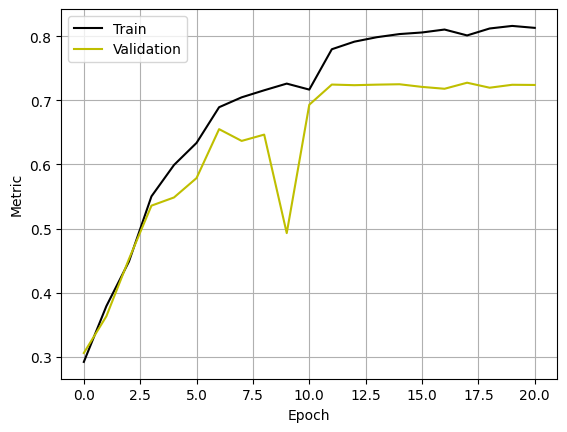


Trained 21 epochs


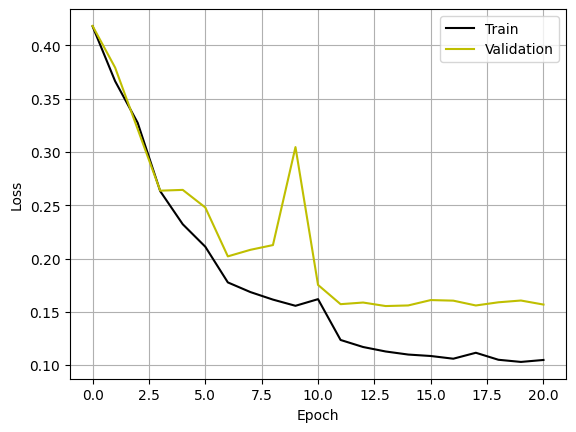

In [12]:
plot(metric_train_hist, metric_valid_hist, "Metric")
plot(loss_train_hist, loss_valid_hist, 'Loss')